In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import os
import pandas as pd
import numpy as np
import librosa
import random
import cv2
from matplotlib import cm

from sklearn.model_selection import train_test_split

from sklearn.pipeline import Pipeline

from transformers import Resampler, BandPassFilter, MelSpectrogramTransformer, SpectrogramPadder, FlattenTransformer, FeatureExtractor, WaveletDenoiser, NoiseAdder, Normalizer

from config import TEST_SIZE, SEED, MAX_DURATION, MIN_DURATION, SAMPLING_RATE, N_MELS, N_FFT

In [33]:
def plot_mel_spectrogram(y, sr=SAMPLING_RATE, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax);

# Conformación del Dataset Final

In [34]:
df = pd.read_csv('./dataset/icbhi/ICBHI_ciclos_metadata.csv')

In [35]:
df['label'] = np.where((df['crackles'] == 0) & (df['wheezes'] == 0), 0, 1)
df.head()

,patient,recording_index,location,mode,instrument,cycle_number,start_sec,end_sec,duration_sec,crackles,wheezes,cycle_wav_file,wav_base_file,age,sex,adult_bmi,child_weight,child_height,diagnosis,label
0,101,1b1,Al,sc,Meditron,1,0.036,0.579,0.543,0,0,101_1b1_Al_sc_Meditron_cycle1.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
1,101,1b1,Al,sc,Meditron,2,0.579,2.450,1.871,0,0,101_1b1_Al_sc_Meditron_cycle2.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
2,101,1b1,Al,sc,Meditron,3,2.450,3.893,1.443,0,0,101_1b1_Al_sc_Meditron_cycle3.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
3,101,1b1,Al,sc,Meditron,4,3.893,5.793,1.900,0,0,101_1b1_Al_sc_Meditron_cycle4.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0
4,101,1b1,Al,sc,Meditron,5,5.793,7.521,1.728,0,0,101_1b1_Al_sc_Meditron_cycle5.wav,101_1b1_Al_sc_Meditron.wav,3.0,F,NaN,19.0,99.0,URTI,0


## Duración de los ciclos respiratorios
La aplicación debería contar con un instructivo mostrando el ritmo de respiración esperado. De esta manera los ciclos detectados por el "segmentador" tendrán mas o menos la misma duración, facilitando la segmentación. 

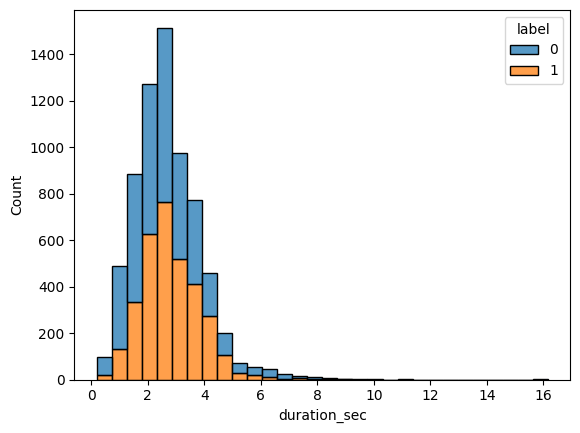

In [36]:
sns.histplot(data=df, x='duration_sec', bins=30, hue='label', multiple='stack');

Las duracion sugerida por el instructivo debería estar en el bulk de la distribución observada.  

¿ Qué hacemos con los ciclos que son demasiado cortos? La segmentación no tolera ciclos demasiado cortos.  

Tampoco debería tolerar los demasiado largos, pero esos son pocos y eliminarlos no es tan costoso.

In [37]:
df = df[df['duration_sec'] < MAX_DURATION].copy()
df = df[df['duration_sec'] > MIN_DURATION].copy()

# Armado del dataset

In [38]:
dataset = 'bp_wd2'

os.makedirs(f'./dataset/ciclos_procesados/{dataset}', exist_ok=True)

In [39]:
X = df['cycle_wav_file'].tolist()
y = df['label'].tolist()

X = [os.path.join('./dataset/audios_ciclos/', path) for path in X]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED, stratify=y
)

In [40]:
noise_paths = os.listdir('./dataset/ruido/train')
noise_paths = [os.path.join('./dataset/ruido/train', path) for path in noise_paths]

test_noise_paths = os.listdir('./dataset/ruido/test')
test_noise_paths = [os.path.join('./dataset/ruido/test', path) for path in test_noise_paths]

In [41]:
random.seed(SEED)

resampler = Resampler()
X_train_resampled = resampler.fit_transform(X_train)
X_test_resampled = resampler.transform(X_test)

In [42]:
white_noise_adder = NoiseAdder(noise_files=[], mode='white', snr_min=5, snr_max=10, random_state=SEED)
real_noise_adder_weak = NoiseAdder(noise_files=noise_paths, mode='pool', snr_min=8, snr_max=10, random_state=SEED)
real_noise_adder = NoiseAdder(noise_files=noise_paths, mode='pool', snr_min=4, snr_max=7, random_state=SEED)
real_noise_adder_strong = NoiseAdder(noise_files=noise_paths, mode='pool', snr_min=1, snr_max=3, random_state=SEED)

white_noise_adder_test = NoiseAdder(noise_files=[], mode='white', snr_min=5, snr_max=10, random_state=SEED)
real_noise_adder_test_weak = NoiseAdder(noise_files=test_noise_paths, mode='pool', snr_min=8, snr_max=10, random_state=SEED)
real_noise_adder_test = NoiseAdder(noise_files=test_noise_paths, mode='pool', snr_min=4, snr_max=7, random_state=SEED)
real_noise_adder_test_strong = NoiseAdder(noise_files=test_noise_paths, mode='pool', snr_min=2, snr_max=4, random_state=SEED)

In [43]:
indices_white_train = random.sample(range(len(X_train_resampled)), int(0.10 * len(X_train_resampled)))
indices_real_weak_train = random.sample(range(len(X_train_resampled)), int(0.70 * len(X_train_resampled)))
indices_real_train  = random.sample(range(len(X_train_resampled)), int(0.80 * len(X_train_resampled)))
indices_real_strong_train = random.sample(range(len(X_train_resampled)), int(0.70 * len(X_train_resampled)))

indices_white_test = random.sample(range(len(X_test_resampled)), int(0.10 * len(X_test_resampled)))
indices_real_weak_test = random.sample(range(len(X_test_resampled)), int(0.70 * len(X_test_resampled)))
indices_real_test  = random.sample(range(len(X_test_resampled)), int(0.80 * len(X_test_resampled)))
indices_real_strong_test = random.sample(range(len(X_test_resampled)), int(0.70 * len(X_test_resampled)))

In [44]:
X_train_white = white_noise_adder.transform([X_train_resampled[i] for i in indices_white_train])
X_train_real_weak = real_noise_adder_weak.transform([X_train_resampled[i] for i in indices_real_weak_train])
X_train_real  = real_noise_adder.transform([X_train_resampled[i] for i in indices_real_train])
X_train_real_strong = real_noise_adder_strong.transform([X_train_resampled[i] for i in indices_real_strong_train])

X_test_white = white_noise_adder_test.transform([X_test_resampled[i] for i in indices_white_test])
X_test_real_weak = real_noise_adder_test_weak.transform([X_test_resampled[i] for i in indices_real_weak_test])
X_test_real  = real_noise_adder_test.transform([X_test_resampled[i] for i in indices_real_test])
X_test_real_strong = real_noise_adder_test_strong.transform([X_test_resampled[i] for i in indices_real_strong_test])

In [45]:
X_train_augmented = (
    X_train_resampled +
    X_train_white +
    X_train_real +
    X_train_real_strong
)
y_train_augmented = (
    y_train +
    [y_train[i] for i in indices_white_train] +
    [y_train[i] for i in indices_real_train] +
    [y_train[i] for i in indices_real_strong_train]
)

X_test_augmented = (
    X_test_resampled +
    X_test_real +
    X_test_real_strong
)
y_test_augmented = (
    y_test +
    [y_test[i] for i in indices_real_test] +
    [y_test[i] for i in indices_real_strong_test]
)

In [48]:
combined = list(zip(X_train_augmented, y_train_augmented))

random.shuffle(combined)

X_train_augmented, y_train_augmented = zip(*combined)

X_train_augmented = list(X_train_augmented)
y_train_augmented = list(y_train_augmented)

#### Mel espectrograma

In [ ]:
pipeline_melspec = Pipeline([
    ('wavelet_denoiser', WaveletDenoiser()),
    ('bandpass', BandPassFilter()),
    ('melspec', MelSpectrogramTransformer()),
    ('pad', SpectrogramPadder()),
    ('flatten', FlattenTransformer())
])

In [18]:
X_train_melspecs_aug = pipeline_melspec.fit_transform(X_train_augmented)
# X_train_melspecs = pipeline_melspec.transform(X_train_resampled)

In [19]:
X_test_melspecs_aug = pipeline_melspec.transform(X_test_augmented)
# X_test_melspecs = pipeline_melspec.transform(X_test_resampled)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [20]:
# print(X_train_melspecs.shape, X_test_melspecs.shape)

print(X_train_melspecs_aug.shape, X_test_melspecs_aug.shape)

(13469, 47616) (3239, 47616)


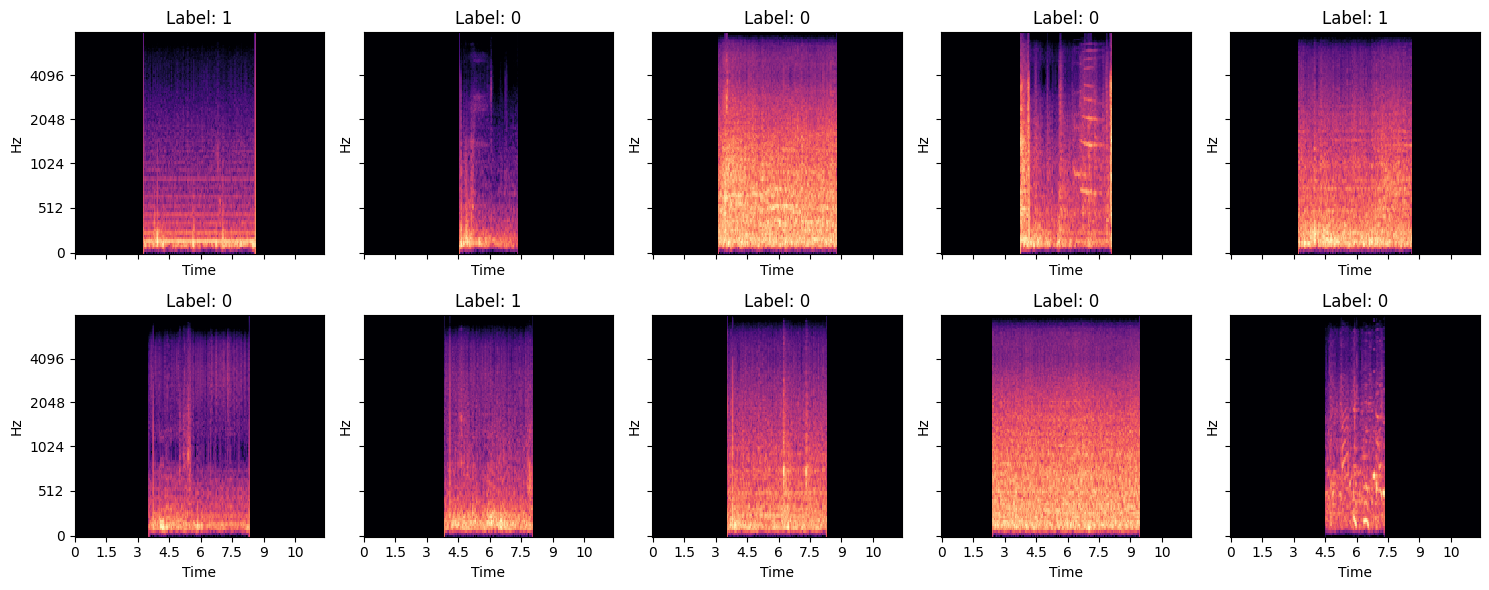

In [22]:
fig, axs = plt.subplots(2, 5, figsize=(15,6), sharey=True, sharex=True)
for i in range(10):
    ax = axs[i//5, i%5]
    img = librosa.display.specshow(X_train_melspecs_aug[-i].reshape(128, -1), sr=16000, x_axis='time', y_axis='mel', n_fft=1024, ax=ax, cmap='magma')
    ax.set_title(f'Label: {y_train[i]}')
plt.tight_layout();

In [23]:
np.savez_compressed(
    f'./dataset/ciclos_procesados/{dataset}/train_melspectrogram.npz',
    X=X_train_melspecs_aug,
    y=y_train_augmented
)

np.savez_compressed(
    f'./dataset/ciclos_procesados/{dataset}/test_melspectrogram.npz',
    X=X_test_melspecs_aug,
    y=y_test_augmented
)

# augmented
# np.savez_compressed(
#     f'./dataset/ciclos_procesados/{dataset}/train_melspectrogram.npz',
#     X=X_train_melspecs,
#     y=y_train
# )

# np.savez_compressed(
#     f'./dataset/ciclos_procesados/{dataset}/test_melspectrogram.npz',
#     X=X_test_melspecs,
#     y=y_test
# )

#### Features

In [ ]:
pipeline_feature_extraction = Pipeline([
    ('wavelet_denoiser', WaveletDenoiser()),
    ('bandpass', BandPassFilter()),
    ('feature_extractor', FeatureExtractor())
])

In [50]:
# X_train_features = pipeline_feature_extraction.fit_transform(X_train_resampled)
X_train_features_aug = pipeline_feature_extraction.transform(X_train_augmented)

c:\Users\nazar\Clasificador-Respiracion\venv\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [51]:
# X_test_features = pipeline_feature_extraction.transform(X_test_resampled)
X_test_features_aug = pipeline_feature_extraction.transform(X_test_augmented)

In [52]:
# np.savez_compressed(
#     f'./dataset/ciclos_procesados/{dataset}/train_features.npz',
#     X=X_train_features,
#     y=y_train
# )

# np.savez_compressed(
#     f'./dataset/ciclos_procesados/{dataset}/test_features.npz',
#     X=X_test_features,
#     y=y_test
# )

# augmented
np.savez_compressed(
    f'./dataset/ciclos_procesados/{dataset}/train_features.npz',
    X=X_train_features_aug,
    y=y_train_augmented
)

np.savez_compressed(
    f'./dataset/ciclos_procesados/{dataset}/test_features.npz',
    X=X_test_features_aug,
    y=y_test_augmented
)

## Imagenes

In [28]:
def plot_mel_spectrogram(y, sr=SAMPLING_RATE, ax=None, cmap='magma'):
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS)
    S_dB = librosa.power_to_db(S, ref=np.max)
    librosa.display.specshow(S_dB, sr=sr, x_axis='time', y_axis='mel', ax=ax, cmap=cmap);

def normalize_spec(spec):
    spec_min, spec_max = spec.min(), spec.max()
    spec = (spec - spec_min) / (spec_max - spec_min + 1e-6)
    spec = (spec * 255).astype(np.uint8)
    return spec

def spec_to_rgb(spec):
    spec = normalize_spec(spec)
    spec_color = cm.magma(spec / 255.0)[:, :, :3]  # RGB float 0–1
    return (spec_color * 255).astype(np.uint8)

def save_mel_images(X, y, split_name, dataset):
    output_dir = f'./dataset/ciclos_procesados/{dataset}/{split_name}_imgs'
    os.makedirs(output_dir, exist_ok=True)

    filenames = []
    for i, spec in enumerate(X):
        spec_rgb = spec_to_rgb(np.flipud(spec))
        # cv2 usa BGR → convertimos para guardar bien los colores
        cv2.imwrite(os.path.join(output_dir, f"{i}.png"), cv2.cvtColor(spec_rgb, cv2.COLOR_RGB2BGR))
        filenames.append(f"{i}.png")

    pd.DataFrame({
        'filename': filenames,
        'label': y
    }).to_csv(f'{output_dir}/labels.csv', index=False)

Guardar imagenes

Para las NN necesito un conjunto de validacion

In [29]:
# X_train_melspecs, X_val_melspecs, y_train, y_val = train_test_split(
#     X_train_melspecs, y_train, test_size=0.2, random_state=SEED, stratify=y_train
# )

X_train_melspecs_aug, X_val_melspecs_aug, y_train_augmented, y_val_augmented = train_test_split(
    X_train_melspecs_aug, y_train_augmented, test_size=0.2, random_state=SEED, stratify=y_train_augmented
)

In [30]:
# save_mel_images(X_train_melspecs.reshape(-1, 128, 372), y_train, 'cnn/train', dataset)
# save_mel_images(X_val_melspecs.reshape(-1, 128, 372), y_val, 'cnn/val', dataset)
# save_mel_images(X_test_melspecs.reshape(-1, 128, 372), y_test, 'cnn/test', dataset)

save_mel_images(X_train_melspecs_aug.reshape(-1, 128, 372), y_train_augmented, 'cnn/train', dataset)
save_mel_images(X_val_melspecs_aug.reshape(-1, 128, 372), y_val_augmented, 'cnn/val', dataset)
save_mel_images(X_test_melspecs_aug.reshape(-1, 128, 372), y_test_augmented, 'cnn/test', dataset)

In [31]:
# np.savez_compressed(
#     f'./dataset/ciclos_procesados/{dataset}/cnn/train_melspectrogram.npz',
#     X=X_train_melspecs,
#     y=y_train
# )

# np.savez_compressed(
#     f'./dataset/ciclos_procesados/{dataset}/cnn/val_melspectrogram.npz',
#     X=X_val_melspecs,
#     y=y_val
# )

# np.savez_compressed(
#     f'./dataset/ciclos_procesados/{dataset}/cnn/test_melspectrogram.npz',
#     X=X_test_melspecs,
#     y=y_test
# )

np.savez_compressed(
    f'./dataset/ciclos_procesados/{dataset}/cnn/train_melspectrogram.npz',
    X=X_train_melspecs_aug,
    y=y_train_augmented
)

np.savez_compressed(
    f'./dataset/ciclos_procesados/{dataset}/cnn/val_melspectrogram.npz',
    X=X_val_melspecs_aug,
    y=y_val_augmented
)

np.savez_compressed(
    f'./dataset/ciclos_procesados/{dataset}/cnn/test_melspectrogram.npz',
    X=X_test_melspecs_aug,
    y=y_test_augmented
)